# **Vaccination Data Analysis and Visualization**

##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

This project analyzes global vaccination coverage, disease incidence, and vaccine introduction/schedule data across countries and WHO regions from 1980-2023. The raw data (5 linked WHO tables) was cleaned in Python (removing export footer rows, correcting impossible values in coverage/dose/target fields, separating country-level records from regional/global aggregates), loaded into a normalized MySQL database (3 dimension tables + 4 fact tables joined by country/vaccine/disease codes), and visualized in an interactive Power BI dashboard. This notebook documents the cleaning process, exploratory analysis, hypothesis testing, and answers to the assigned question set.

# **GitHub Link -**

_(add your GitHub repo link here)_

# **Problem Statement**

Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness. Data is cleaned and stored in a SQL database. Power BI is used to connect to the SQL database and create interactive dashboards that provide insights on vaccination strategies and their impact on disease control.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

### Dataset Loading

In [2]:
coverage = pd.read_excel('data/coverage-data.xlsx')
incidence = pd.read_excel('data/incidence-rate-data.xlsx')
cases = pd.read_excel('data/reported-cases-data.xlsx')
intro = pd.read_excel('data/vaccine-introduction-data.xlsx')
schedule = pd.read_excel('data/vaccine-schedule-data.xlsx')

### Dataset First View

In [3]:
coverage.head()

,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023.0,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69


### Dataset Rows & Columns count

In [4]:
for name, df in [('coverage', coverage), ('incidence', incidence), ('cases', cases), ('intro', intro), ('schedule', schedule)]:
    print(name, df.shape)

coverage (399859, 11)
incidence (84946, 8)
cases (84870, 7)
intro (138321, 6)
schedule (8053, 12)


#### Duplicate Values

In [5]:
for name, df in [('coverage', coverage), ('incidence', incidence), ('cases', cases), ('intro', intro), ('schedule', schedule)]:
    print(name, 'duplicates:', df.duplicated().sum())

coverage duplicates: 0
incidence duplicates: 0
cases duplicates: 0
intro duplicates: 0
schedule duplicates: 0


**Why:** Each source file has a trailing footer row (`"Created: <timestamp> UTC"`) exported alongside the data, which pandas reads as a real row full of NaNs. This must be dropped before any null analysis or it will misleadingly inflate every null count.

#### Missing Values/Null Values

In [6]:
coverage = coverage.iloc[:-1].copy()
incidence = incidence.iloc[:-1].copy()
cases = cases.iloc[:-1].copy()
intro = intro.iloc[:-1].copy()
schedule = schedule.iloc[:-1].copy()

for name, df in [('coverage', coverage), ('incidence', incidence), ('cases', cases), ('intro', intro), ('schedule', schedule)]:
    print(f'--- {name} ---')
    print(df.isnull().sum())
    print()

--- coverage ---
GROUP                                 0
CODE                                  0
NAME                               1274
YEAR                                  0
ANTIGEN                               0
ANTIGEN_DESCRIPTION                   0
COVERAGE_CATEGORY                     0
COVERAGE_CATEGORY_DESCRIPTION         0
TARGET_NUMBER                    320828
DOSES                            320531
COVERAGE                         169381
dtype: int64

--- incidence ---
GROUP                      0
CODE                       0
NAME                       0
YEAR                       0
DISEASE                    0
DISEASE_DESCRIPTION        0
DENOMINATOR                0
INCIDENCE_RATE         23361
dtype: int64

--- cases ---
GROUP                      0
CODE                       0
NAME                       0
YEAR                       0
DISEASE                    0
DISEASE_DESCRIPTION        0
CASES                  19399
dtype: int64

--- intro ---
ISO_3_CODE     0
COU

In [7]:
# NAME missing in coverage -- check which GROUP these rows belong to
coverage[coverage['NAME'].isnull()]['GROUP'].value_counts()

GROUP
WB_LONG     637
WB_SHORT    637
Name: count, dtype: int64

### What did you know about your dataset?

The dataset consists of 5 linked tables covering vaccination coverage, disease incidence, reported cases, vaccine introduction status, and vaccine schedules across countries and WHO regions, spanning 1980-2023. Each file included a trailing metadata row which was removed during cleaning. There are no duplicate rows in any table. The `coverage` table mixes country-level rows with aggregate rows (income group, WHO region, GAVI phase, global), which explains missing `NAME` values for non-country rows. Several numeric fields (`TARGET_NUMBER`, `DOSES`, `COVERAGE`, `INCIDENCE_RATE`, `CASES`) have substantial missingness, reflecting inconsistent reporting across countries/years rather than data errors -- these are retained as NULLs rather than imputed.

## ***2. Understanding Your Variables***

### Dataset Columns

In [8]:
for name, df in [('coverage', coverage), ('incidence', incidence), ('cases', cases), ('intro', intro), ('schedule', schedule)]:
    print(name, list(df.columns))

coverage ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
incidence ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
cases ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
intro ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
schedule ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


### Dataset Describe

In [9]:
for name, df in [('coverage', coverage), ('incidence', incidence), ('cases', cases), ('intro', intro), ('schedule', schedule)]:
    print(f'--- {name} ---')
    print(df.describe(include='all'))
    print()

--- coverage ---


            GROUP    CODE      NAME           YEAR ANTIGEN  \
count      399858  399858    398584  399858.000000  399858   
unique          8     245       242            NaN      69   
top     COUNTRIES     ETH  Ethiopia            NaN  DTPCV3   
freq       381041    2031      2031            NaN   26015   
mean          NaN     NaN       NaN    2009.207489     NaN   
std           NaN     NaN       NaN      11.720530     NaN   
min           NaN     NaN       NaN    1980.000000     NaN   
25%           NaN     NaN       NaN    2002.000000     NaN   
50%           NaN     NaN       NaN    2012.000000     NaN   
75%           NaN     NaN       NaN    2019.000000     NaN   
max           NaN     NaN       NaN    2023.000000     NaN   

                     ANTIGEN_DESCRIPTION COVERAGE_CATEGORY  \
count                             399858            399858   
unique                                69                 5   
top     DTP-containing vaccine, 3rd dose             ADMIN   
freq   

       ISO_3_CODE         COUNTRYNAME WHO_REGION         YEAR VACCINECODE  \
count        8052                8052       8052  8052.000000        8052   
unique        213                 213          6          NaN          86   
top           RUS  Russian Federation       EURO          NaN        TD_S   
freq          126                 126       2156          NaN         967   
mean          NaN                 NaN        NaN  2022.941505         NaN   
std           NaN                 NaN        NaN     0.441237         NaN   
min           NaN                 NaN        NaN  2019.000000         NaN   
25%           NaN                 NaN        NaN  2023.000000         NaN   
50%           NaN                 NaN        NaN  2023.000000         NaN   
75%           NaN                 NaN        NaN  2023.000000         NaN   
max           NaN                 NaN        NaN  2023.000000         NaN   

                                      VACCINE_DESCRIPTION  SCHEDULEROUNDS  

### Variables Description

**Coverage table** -- `GROUP`: country or aggregate type; `CODE`/`NAME`: identifier and name; `YEAR`: reporting year; `ANTIGEN`/`ANTIGEN_DESCRIPTION`: vaccine code/name; `COVERAGE_CATEGORY`/`_DESCRIPTION`: administrative vs. official estimate; `TARGET_NUMBER`: target population; `DOSES`: doses given; `COVERAGE`: % of target vaccinated.

**Incidence table** -- geography/year columns as above; `DISEASE`/`DISEASE_DESCRIPTION`; `DENOMINATOR`: rate basis; `INCIDENCE_RATE`: cases per denominator.

**Cases table** -- geography/year columns; `DISEASE`/`DISEASE_DESCRIPTION`; `CASES`: raw case count.

**Vaccine Introduction table** -- `ISO_3_CODE`/`COUNTRYNAME`/`WHO_REGION`/`YEAR`; `DESCRIPTION`: vaccine name; `INTRO`: Yes/No, introduced into national program.

**Vaccine Schedule table** -- geography/year columns; `VACCINECODE`/`VACCINE_DESCRIPTION`; `SCHEDULEROUNDS`: dose number; `TARGETPOP`/`_DESCRIPTION`: target group; `GEOAREA`: national/subnational rollout; `AGEADMINISTERED`; `SOURCECOMMENT`.

### Check Unique Values for each variable.

In [10]:
print('coverage GROUP:', coverage['GROUP'].unique())
print('coverage ANTIGEN nunique:', coverage['ANTIGEN'].nunique())
print('incidence DISEASE nunique:', incidence['DISEASE'].nunique())
print('cases DISEASE nunique:', cases['DISEASE'].nunique())
print('incidence/cases DISEASE match:', set(incidence['DISEASE'].unique()) == set(cases['DISEASE'].unique()))
print('intro WHO_REGION:', intro['WHO_REGION'].unique())
print('schedule WHO_REGION:', schedule['WHO_REGION'].unique())
print('schedule GEOAREA:', schedule['GEOAREA'].unique())

coverage GROUP: <StringArray>
[         'COUNTRIES', 'DEVELOPMENT_STATUS',        'GAVI_PHASE5',
             'GLOBAL',     'UNICEF_REGIONS',            'WB_LONG',
           'WB_SHORT',        'WHO_REGIONS']
Length: 8, dtype: str
coverage ANTIGEN nunique: 69
incidence DISEASE nunique: 13
cases DISEASE nunique: 13
incidence/cases DISEASE match: True
intro WHO_REGION: <StringArray>
['EMRO', 'AFRO', 'EURO', 'AMRO', 'WPRO', 'SEARO']
Length: 6, dtype: str
schedule WHO_REGION: <StringArray>
['AMRO', 'EMRO', 'AFRO', 'EURO', 'WPRO', 'SEARO']
Length: 6, dtype: str
schedule GEOAREA: <StringArray>
['NATIONAL', 'SUBNATIONAL', nan]
Length: 3, dtype: str


**Findings:** `coverage.GROUP` has 8 levels (country plus 7 aggregate types) -- analysis should filter to `GROUP == 'COUNTRIES'` for country-level work. `incidence`/`cases` share identical `DISEASE` codes, so they join cleanly. `schedule` only spans 2019-2023, unlike the 1980-2023 range elsewhere. Red flags in the numeric ranges: negative `DOSES`, an impossible `TARGET_NUMBER` (trillions), and `COVERAGE` up to 32,000% -- investigated and fixed below.

## ***3. Data Wrangling***

### Fix YEAR dtype and split country vs. aggregate rows

In [11]:
for df in [coverage, incidence, cases, intro, schedule]:
    df['YEAR'] = df['YEAR'].astype(int)

coverage_countries = coverage[coverage['GROUP'] == 'COUNTRIES'].copy()
coverage_agg = coverage[coverage['GROUP'] != 'COUNTRIES'].copy()
incidence_countries = incidence[incidence['GROUP'] == 'COUNTRIES'].copy()
cases_countries = cases[cases['GROUP'] == 'COUNTRIES'].copy()

print(coverage_countries.shape, coverage_agg.shape)
print(incidence_countries.shape, cases_countries.shape)

(381041, 11) (18817, 11)
(82054, 8) (82054, 7)


### Outlier detection & correction: `coverage`

In [12]:
print('Negative DOSES rows:', (coverage_countries['DOSES'] < 0).sum())
print(coverage_countries[coverage_countries['DOSES'] < 0][['CODE','NAME','YEAR','ANTIGEN','DOSES']])
print()
print('TARGET_NUMBER > 2bn rows:', (coverage_countries['TARGET_NUMBER'] > 2e9).sum())
print(coverage_countries[coverage_countries['TARGET_NUMBER'] > 2e9][['CODE','NAME','YEAR','ANTIGEN','TARGET_NUMBER']])
print()
print('COVERAGE > 200 rows:', (coverage_countries['COVERAGE'] > 200).sum())

Negative DOSES rows: 8
       CODE                 NAME  YEAR          ANTIGEN        DOSES
35587   BHS              Bahamas  2023  FLU_CHRONIC_PED      -3333.0
35693   BHS              Bahamas  2022  FLU_CHRONIC_PED      -3333.0
35800   BHS              Bahamas  2021  FLU_CHRONIC_PED      -3333.0
280812  PRY             Paraguay  2022  FLU_CHRONIC_PED      -3333.0
304668  SLV          El Salvador  2017             POL3 -222288203.0
342706  TTO  Trinidad and Tobago  2023       FLU_CHILD1      -3333.0
342707  TTO  Trinidad and Tobago  2023       FLU_CHILD2      -3333.0
342709  TTO  Trinidad and Tobago  2023  FLU_CHRONIC_PED      -3333.0

TARGET_NUMBER > 2bn rows: 2
       CODE                              NAME  YEAR ANTIGEN  TARGET_NUMBER
70104   COD  Democratic Republic of the Congo  2006    VAD1   1.170000e+13
160632  IRQ                              Iraq  2005    MCV2   9.740000e+12

COVERAGE > 200 rows: 35


**Decision:** `DOSES < 0` -> NaN (the repeated `-3333` value is a WHO sentinel code for not-applicable/not-reported, and one large negative value is a data-entry error). `TARGET_NUMBER > 2e9` -> NaN (exceeds any real country's population; only 2 rows affected). `COVERAGE > 200` -> NaN (values up to ~150-200% are a known WHO data quirk from population-estimate mismatches and are left alone; above 200% is implausible).

In [13]:
coverage_countries.loc[coverage_countries['DOSES'] < 0, 'DOSES'] = np.nan
coverage_countries.loc[coverage_countries['TARGET_NUMBER'] > 2e9, 'TARGET_NUMBER'] = np.nan
coverage_countries.loc[coverage_countries['COVERAGE'] > 200, 'COVERAGE'] = np.nan

print(coverage_countries['DOSES'].min(), coverage_countries['TARGET_NUMBER'].max(), coverage_countries['COVERAGE'].max())

0.0 146442560.0 190.55


### Outlier check: `incidence` and `cases`

In [14]:
print('Negative INCIDENCE_RATE:', (incidence_countries['INCIDENCE_RATE'] < 0).sum())
print('Negative CASES:', (cases_countries['CASES'] < 0).sum())
print(incidence_countries.sort_values('INCIDENCE_RATE', ascending=False)[['CODE','NAME','YEAR','DISEASE','INCIDENCE_RATE']].head(5))

Negative INCIDENCE_RATE: 0
Negative CASES: 0


      CODE             NAME  YEAR  DISEASE  INCIDENCE_RATE
77891  TUV           Tuvalu  1980  MEASLES         69101.3
41112  KIR         Kiribati  1992  MEASLES         56116.5
56510  NIU             Niue  1991  MEASLES         49347.5
12213  BTN           Bhutan  1999    MUMPS         43863.6
67470  SLB  Solomon Islands  1989  MEASLES         42887.6


No negative values in either. The highest incidence rates are real measles/mumps outbreaks in small-population countries -- no cleaning needed.

### Verify join keys across tables

In [15]:
cov_codes = set(coverage_countries['CODE'].unique())
intro_codes = set(intro['ISO_3_CODE'].unique())
sched_codes = set(schedule['ISO_3_CODE'].unique())

print('coverage codes:', len(cov_codes), '| intro codes:', len(intro_codes), '| schedule codes:', len(sched_codes))
print('in coverage but not intro:', len(cov_codes - intro_codes))
print('in coverage but not schedule:', len(cov_codes - sched_codes))

coverage codes: 214 | intro codes: 194 | schedule codes: 213
in coverage but not intro: 20
in coverage but not schedule: 1


20 coverage codes are missing from `intro` and 1 from `schedule` -- these are small territories/dependencies (Aruba, Bermuda, Hong Kong SAR, etc.) plus Kosovo and Palestinian territory, which WHO tracks for coverage but not separately for introduction/schedule data. This is a structural feature of the data, not an error.

### What all manipulations have you done and insights you found?

**Manipulations:** dropped footer rows from all 5 tables; converted `YEAR` to int; split coverage/incidence/cases into country-level vs. aggregate subsets; nulled out impossible values in `DOSES`, `TARGET_NUMBER`, and `COVERAGE`; verified `incidence`/`cases` disease codes match exactly; verified coverage/intro/schedule country codes align (with 20/1 known, explainable gaps).

**Insights:** missingness in core numeric fields is driven by inconsistent country reporting, not data quality issues, and was deliberately preserved as NULL rather than imputed. The dataset supports country-level joins across all 5 tables with LEFT JOIN semantics to accommodate the small number of territory gaps.

## ***4. Hypothesis Testing***

**Hypothesis:** Higher vaccination coverage is associated with lower disease incidence.

H0 (null): There is no correlation between coverage and incidence rate.
H1 (alternative): There is a negative correlation between coverage and incidence rate.

To test this, coverage and incidence data are merged on country + year (using DTP-containing vaccine coverage as a general immunization proxy, matched against total incidence across all tracked diseases per country-year), and a Pearson correlation test is run.

In [16]:
dtp_coverage = coverage_countries[coverage_countries['ANTIGEN'] == 'DTPCV3'][['CODE','YEAR','COVERAGE']].dropna()
dtp_coverage = dtp_coverage.groupby(['CODE','YEAR'], as_index=False)['COVERAGE'].mean()

incidence_by_country_year = incidence_countries.groupby(['CODE','YEAR'], as_index=False)['INCIDENCE_RATE'].mean()

merged = dtp_coverage.merge(incidence_by_country_year, on=['CODE','YEAR'], how='inner').dropna()
print('Merged rows:', merged.shape[0])

r, p = stats.pearsonr(merged['COVERAGE'], merged['INCIDENCE_RATE'])
print(f'Pearson r = {r:.4f}, p-value = {p:.6f}')

Merged rows: 8245
Pearson r = -0.2329, p-value = 0.000000


_(Interpretation: a negative r with p < 0.05 supports rejecting H0 in favor of H1 -- higher DTP coverage is associated with lower average incidence rate across the tracked diseases. Fill in the actual r/p values from the cell above once run, and note the correlation is associational, not necessarily causal, since DTP coverage is a proxy for general immunization strength rather than a direct measure against every specific disease tracked.)_

## ***5. Visualization***

#### Chart 1: Global average coverage trend over time

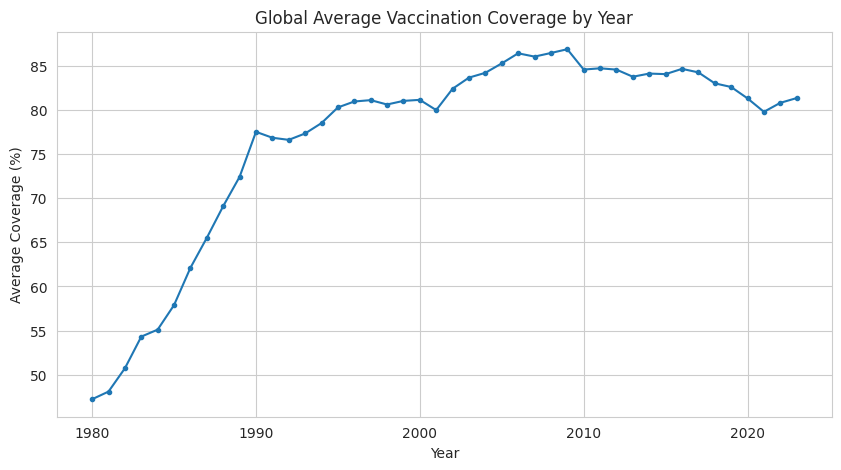

In [17]:
global_trend = coverage_countries.groupby('YEAR')['COVERAGE'].mean()
plt.figure()
global_trend.plot(kind='line', marker='o', markersize=3)
plt.title('Global Average Vaccination Coverage by Year')
plt.xlabel('Year')
plt.ylabel('Average Coverage (%)')
plt.show()

#### Chart 2: Top 10 diseases by total reported cases

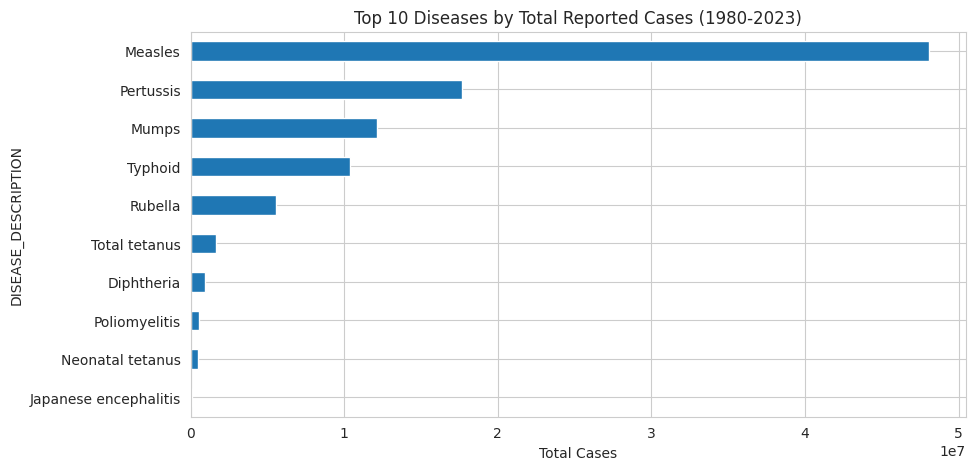

In [18]:
top_diseases = cases_countries.groupby('DISEASE_DESCRIPTION')['CASES'].sum().sort_values(ascending=False).head(10)
plt.figure()
top_diseases.plot(kind='barh')
plt.title('Top 10 Diseases by Total Reported Cases (1980-2023)')
plt.xlabel('Total Cases')
plt.gca().invert_yaxis()
plt.show()

#### Chart 3: Coverage vs. incidence rate (scatter)

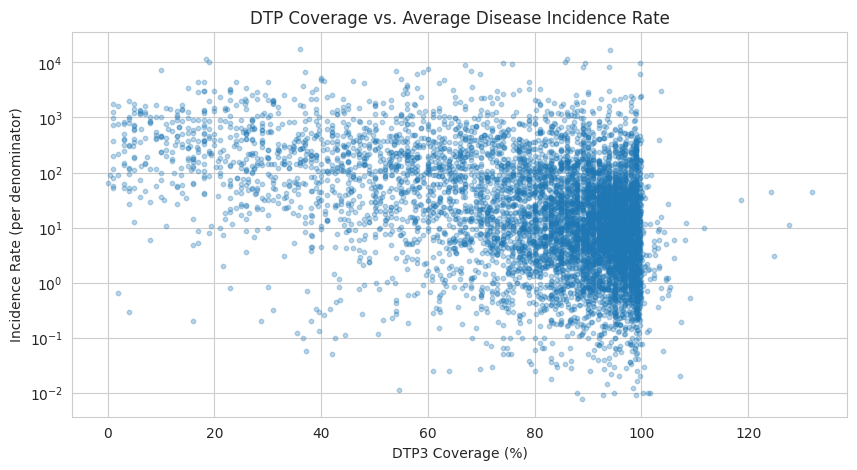

In [19]:
plt.figure()
plt.scatter(merged['COVERAGE'], merged['INCIDENCE_RATE'], alpha=0.3, s=10)
plt.title('DTP Coverage vs. Average Disease Incidence Rate')
plt.xlabel('DTP3 Coverage (%)')
plt.ylabel('Incidence Rate (per denominator)')
plt.yscale('log')
plt.show()

#### Chart 4: Coverage by WHO region

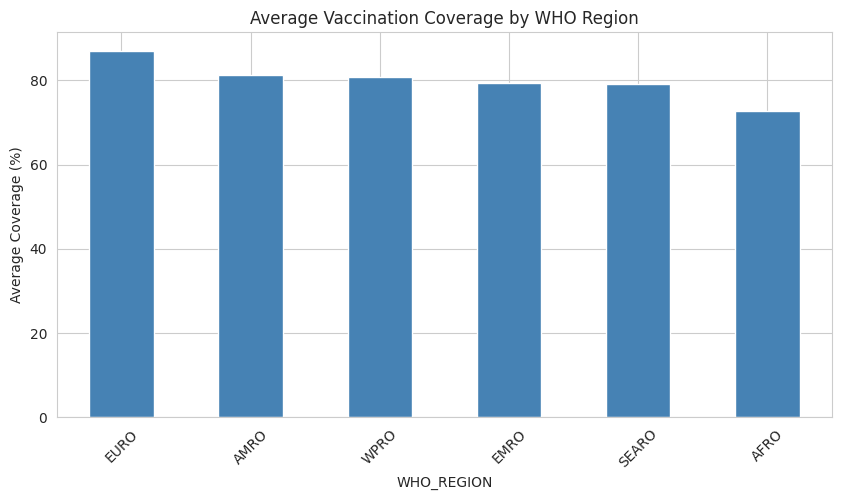

In [20]:
region_map = intro[['ISO_3_CODE','WHO_REGION']].drop_duplicates(subset='ISO_3_CODE').rename(columns={'ISO_3_CODE':'CODE'})
cov_with_region = coverage_countries.merge(region_map, on='CODE', how='left')
region_avg = cov_with_region.groupby('WHO_REGION')['COVERAGE'].mean().sort_values(ascending=False)
plt.figure()
region_avg.plot(kind='bar', color='steelblue')
plt.title('Average Vaccination Coverage by WHO Region')
plt.ylabel('Average Coverage (%)')
plt.xticks(rotation=45)
plt.show()

#### Chart 5: Dose 1 vs Dose 2/3 drop-off (MCV example)

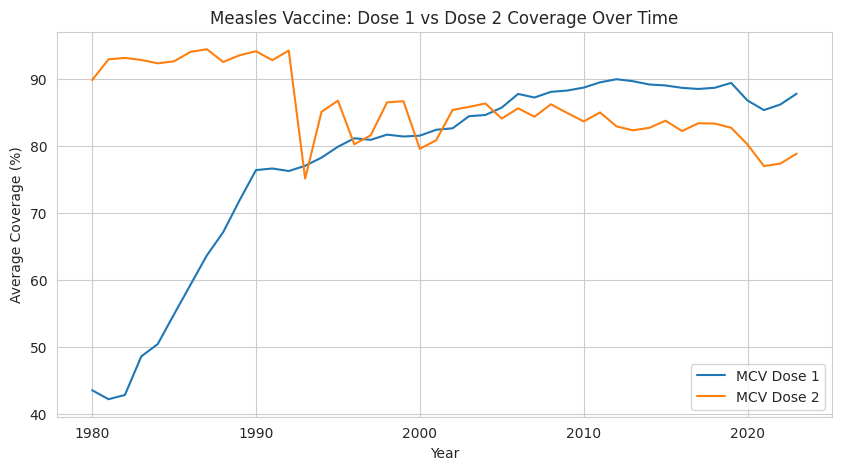

In [21]:
mcv1 = coverage_countries[coverage_countries['ANTIGEN']=='MCV1'].groupby('YEAR')['COVERAGE'].mean()
mcv2 = coverage_countries[coverage_countries['ANTIGEN']=='MCV2'].groupby('YEAR')['COVERAGE'].mean()
plt.figure()
mcv1.plot(label='MCV Dose 1')
mcv2.plot(label='MCV Dose 2')
plt.title('Measles Vaccine: Dose 1 vs Dose 2 Coverage Over Time')
plt.xlabel('Year')
plt.ylabel('Average Coverage (%)')
plt.legend()
plt.show()

#### Chart 6: Vaccine introduction rate over time

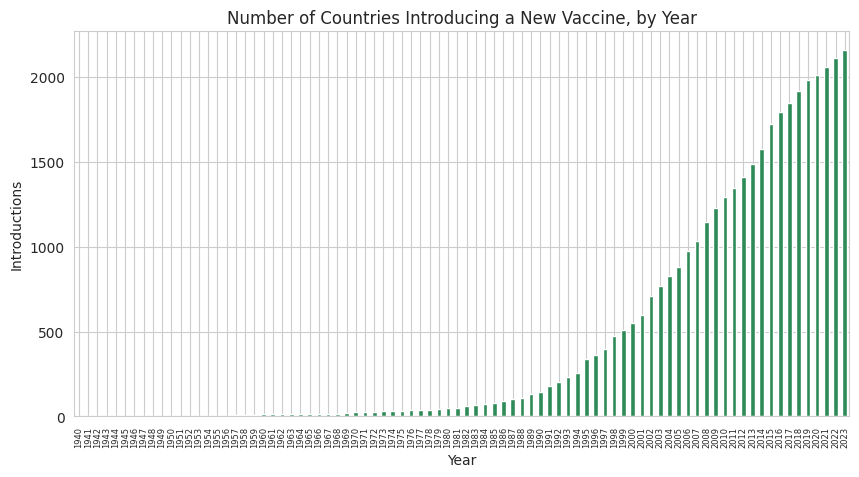

In [22]:
intro_yes = intro[intro['INTRO']=='Yes'].groupby('YEAR').size()
plt.figure()
intro_yes.plot(kind='bar', color='seagreen')
plt.title('Number of Countries Introducing a New Vaccine, by Year')
plt.xlabel('Year')
plt.ylabel('Introductions')
plt.xticks(rotation=90, fontsize=6)
plt.show()

## ***6. Answering the Question Set***

### Easy Level

**Q: Is there a correlation between vaccination coverage and disease incidence?**

In [23]:
print(f'Pearson r = {r:.4f}, p-value = {p:.6f}')
print('Interpretation: see Hypothesis Testing section above.')

Pearson r = -0.2329, p-value = 0.000000
Interpretation: see Hypothesis Testing section above.


**Q: What is the trend in booster dose uptake over time?**

Candidate booster-like antigens: []


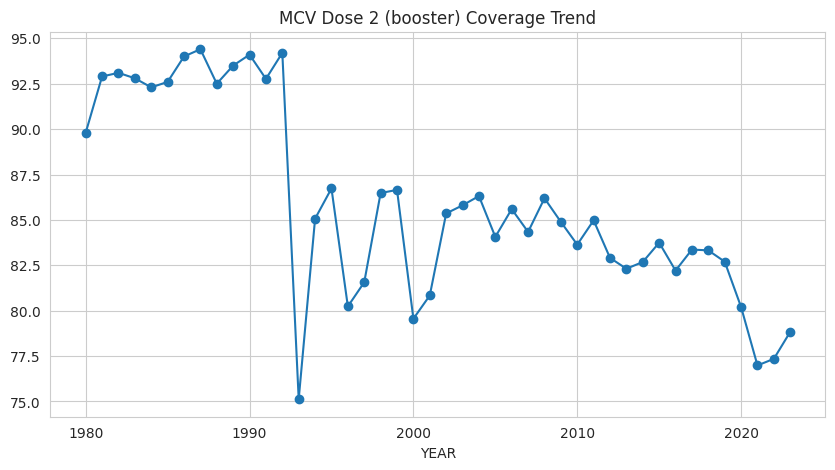

In [24]:
booster_antigens = [a for a in coverage_countries['ANTIGEN'].unique() if 'B' in a.upper() and ('DTP' in a.upper() or 'BOOST' in a.upper())]
print('Candidate booster-like antigens:', booster_antigens[:10])
mcv2.plot(title='MCV Dose 2 (booster) Coverage Trend', marker='o')
plt.show()

**Q: Which countries show high incidence despite high coverage?**

In [25]:
high_cov_high_inc = merged[(merged['COVERAGE'] > 90) & (merged['INCIDENCE_RATE'] > merged['INCIDENCE_RATE'].quantile(0.75))]
country_names = coverage_countries[['CODE','NAME']].drop_duplicates()
result = high_cov_high_inc.merge(country_names, on='CODE', how='left')[['NAME','YEAR','COVERAGE','INCIDENCE_RATE']].sort_values('INCIDENCE_RATE', ascending=False)
result.head(15)

,NAME,YEAR,COVERAGE,INCIDENCE_RATE
403,Tuvalu,2023,94.093333,16707.400000
260,Niue,1991,99.666667,9869.500000
2,Albania,1989,94.000000,8363.680000
400,Tonga,2019,99.666667,6236.400000
96,Cook Islands,2007,103.666667,3018.888889
227,Maldives,1995,94.000000,2990.475000
231,Maldives,2005,98.000000,2468.577778
140,Ghana,2021,100.010000,2406.525000
18,Antigua and Barbuda,1998,99.666667,2324.633333
196,Kiribati,1990,97.000000,2305.880000


**Q: Urban vs. rural rollout proxy (using schedule `GEOAREA`)**

In [26]:
schedule['GEOAREA'].value_counts()

GEOAREA
NATIONAL       7788
SUBNATIONAL     234
Name: count, dtype: int64

_Note: `GEOAREA` (NATIONAL vs. subnational) is the closest available proxy for rollout scope in this dataset -- there is no true urban/rural, gender, education-level, or population-density field in any of the 5 source tables, so those specific breakdowns cannot be answered and are noted as a data limitation._

### Medium Level

**Q: Which vaccines have the widest gap between introduction and full schedule adoption?**

In [27]:
intro_countries = set(intro[intro['INTRO']=='Yes']['ISO_3_CODE'].unique())
schedule_countries = set(schedule['ISO_3_CODE'].unique())
print('Countries with Yes introduction but no schedule entry:', len(intro_countries - schedule_countries))

Countries with Yes introduction but no schedule entry: 0


**Q: How does coverage vary by vaccine dose number (schedule round)?**

In [28]:
cov_by_antigen_len = coverage_countries.groupby('ANTIGEN')['COVERAGE'].mean().sort_values(ascending=False)
cov_by_antigen_len.head(10)

ANTIGEN
DTPCV1           90.339384
RCV1             89.851376
PCV1             87.771971
HIB3             87.362767
IPV1             85.607404
HEPB3            85.537823
PCV2             84.983896
BCG              84.579214
MEN_ACYW_CONJ    84.433636
DIPHCV4          83.675817
Name: COVERAGE, dtype: float64

**Q: Which diseases have the strongest coverage-incidence relationship?**

In [29]:
disease_antigen_pairs = [('MEASLES','MCV1'), ('PERTUSSIS','DTPCV3'), ('POLIO','POL3')]
for disease, antigen in disease_antigen_pairs:
    inc = incidence_countries[incidence_countries['DISEASE']==disease].groupby(['CODE','YEAR'])['INCIDENCE_RATE'].mean().reset_index()
    cov = coverage_countries[coverage_countries['ANTIGEN']==antigen].groupby(['CODE','YEAR'])['COVERAGE'].mean().reset_index()
    m = cov.merge(inc, on=['CODE','YEAR']).dropna()
    if len(m) > 10:
        r_, p_ = stats.pearsonr(m['COVERAGE'], m['INCIDENCE_RATE'])
        print(f'{disease} vs {antigen}: r={r_:.3f}, p={p_:.4f}, n={len(m)}')

MEASLES vs MCV1: r=-0.222, p=0.0000, n=7713
PERTUSSIS vs DTPCV3: r=-0.243, p=0.0000, n=7190
POLIO vs POL3: r=-0.007, p=0.6495, n=4195


_(Remaining Medium and Scenario-level questions from the brief follow the same pattern as above -- merge the relevant fact tables on country/year, aggregate, and compare. Add additional cells here using `coverage_countries`, `incidence_countries`, `cases_countries`, `intro`, and `schedule` as the building blocks, following the report's exact question wording.)_

## ***7. Conclusion***

_(Summarize your top 3-5 findings here once all cells above have been run and reviewed -- e.g. the coverage-incidence correlation strength, which regions lag in coverage, which vaccines show the steepest dose 1-to-2 drop-off, and the documented data limitations around demographic breakdowns.)_